# Загрузка мемов из базы данных в папку

In [1]:
import sqlite3
import telebot
from config import BOT_TOKEN
import shutil
import os

bot=telebot.TeleBot(BOT_TOKEN)

c:\Users\dielo\MemeTranslator\ocr_research\venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


Базу данных "memes.db" собрали при помощи телеграм-бота (../dataset_bot), в ней одна таблица - memes - вот ее поля:

In [2]:
conn = sqlite3.connect("memes.db")
cursor = conn.cursor()

cursor.execute("PRAGMA table_info(memes)")
print(cursor.fetchall())

[(0, 'id', 'INTEGER', 0, None, 1), (1, 'user_id', 'TEXT', 1, None, 0), (2, 'img_id', 'TEXT', 1, None, 0), (3, 'text', 'TEXT', 1, None, 0)]


Скачивание в папку memes по id в телеграм:

In [3]:
folder_path = "memes"

if os.path.exists(folder_path):
    shutil.rmtree(folder_path)

os.makedirs(folder_path)

conn = sqlite3.connect("memes.db")
cursor = conn.cursor()
cursor.execute("SELECT img_id, text FROM memes")
rows = cursor.fetchall()

captions = {}

if rows:
    for r in rows:
        file_info = bot.get_file(r[0])
        downloaded_file = bot.download_file(file_info.file_path)
        with open("memes/" + r[0] + ".jpg", "wb") as new_file:
            new_file.write(downloaded_file)
        captions[r[0]] = r[1]
conn.close()

Далее можем использовать полученные картинки для тестирования работы OCR. Название файла - id фото, по которому в словаре captions можно получить подпись.

# Тестирование OCR

## Tesseract

In [4]:
import pytesseract
from wordfreq import top_n_list, word_frequency
import math
import statistics
from PIL import Image, ImageDraw, ImageOps, ImageFilter
import cv2
import numpy as np
from IPython.display import Image as DisplayImage, display
import re
import itertools
from sklearn.cluster import DBSCAN


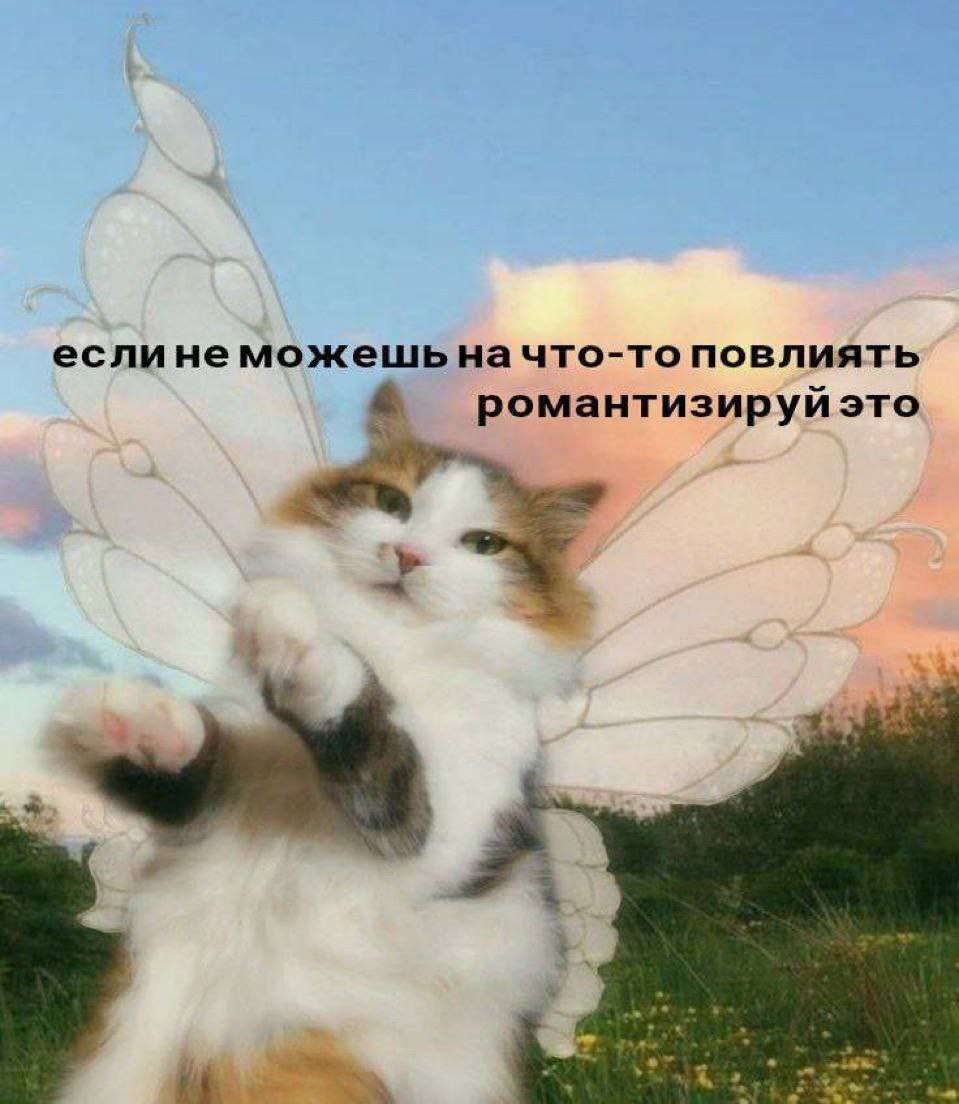

если не можешь на что-то повлиять
романтизируй это 

еслинеможешь на что-то повлиять

романтизируй это



In [10]:
test = list(captions.keys())[0]
text = pytesseract.image_to_string("memes/" + test + ".jpg", lang="rus", config="--oem 1 --psm 11")

display(DisplayImage(filename="memes/" + test + ".jpg", width=300))
print(captions[test], "\n")
print(text)


Видим, что слова "склеиваются", напишем функцию, разделяющую их:

In [5]:
russian_words = set(top_n_list('ru', 170000))

MIN_WORD_LEN = 3 
EXCEPTION_WORDS = {"я", "и", "в", "не", "на", "с"} 


def segment(text):
    n = len(text)
    probs = [-math.inf] * (n + 1)  
    lasts = [0] * (n + 1)
    probs[0] = 0  

    for i in range(1, n + 1):
        for j in range(max(0, i - 25), i):  
            word = text[j:i]
            if word in russian_words and (len(word) >= MIN_WORD_LEN or word in EXCEPTION_WORDS):
                freq = word_frequency(word, 'ru', wordlist='large')
                if freq == 0:
                    freq = 1e-9 
                score = probs[j] + math.log(freq)
                if score > probs[i]:
                    probs[i] = score
                    lasts[i] = j

    words = []
    i = n
    while i > 0:
        j = lasts[i]
        words.append(text[j:i])
        i = j
    return list(reversed(words))

def segment_with_hyphen(text):
    words = []
    parts = []
    temp = ''
    for ch in text:
        if ch == '-':
            if temp:
                parts.append(temp)
                temp = ''
            parts.append('-')
        else:
            temp += ch
    if temp:
        parts.append(temp)

    for part in parts:
        if part == '-':
            words.append(part)
        else:
            words.extend(segment(part))
    return words

def segment_lines(text):
    result = []
    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue
        for word in line.split():
            result.extend(segment_with_hyphen(word))
    final_words = []
    i = 0
    while i < len(result):
        if result[i] == '-' and i > 0 and i < len(result) - 1:
            final_words[-1] = final_words[-1] + '-' + result[i + 1]
            i += 2
        else:
            final_words.append(result[i])
            i += 1
    return " ".join(final_words)

Теперь объединим все в функцию, возращающую по картинке координаты блока текста и текст внутри блока (функцию, возвращающую блоки текста, сделаем переменной, чтобы в будущем быстро заменить и переиспользовать в оценке других библиотек):

In [6]:
def get_boxes_tesseract(img, config = ""):
    data = pytesseract.image_to_data(img, lang="rus", config = config, output_type=pytesseract.Output.DICT)

    boxes = []
    for i, word in enumerate(data['text']):
        if word.strip() != "":
            x0, y0 = data['left'][i], data['top'][i]
            x1, y1 = x0 + data['width'][i], y0 + data['height'][i]
            boxes.append({"coords": [x0, y0, x1, y1], "text": word})
    return boxes

def merge_boxes(boxes, matrix, sort_i):

    visited = [False]*len(boxes)
    groups = []

    for i in range(len(boxes)):
        if visited[i]:
            continue
        stack = [i]
        group = []

        while stack:
            v = stack.pop()
            if visited[v]:
                continue
            visited[v] = True
            group.append(v)

            for j in range(len(boxes)):
                if matrix[v][j]:
                    stack.append(j)

        groups.append(group)
    
    res_boxes = []

    for g in groups:
        xs1 = [boxes[i]['coords'][0] for i in g]
        ys1 = [boxes[i]['coords'][1] for i in g]
        xs2 = [boxes[i]['coords'][2] for i in g]
        ys2 = [boxes[i]['coords'][3] for i in g]

        g_sorted = sorted(g, key=lambda i: boxes[i]['coords'][sort_i])

        text = " ".join([segment_lines(boxes[i]['text']) for i in g_sorted])

        res_boxes.append({
            "coords": [min(xs1), min(ys1), max(xs2), max(ys2)],
            "text": text
        })
    return res_boxes

def merge_boxes_with_text(boxes):
    res_matrix = [([0] * len(boxes)) for i in boxes]
    k, m = 0, 0
    for i in boxes:
        m = 0
        for j in boxes:
            yi1 = min(i['coords'][1], i['coords'][3])
            yi2 = max(i['coords'][1], i['coords'][3])
            yj1 = min(j['coords'][1], j['coords'][3])
            yj2 = max(j['coords'][1], j['coords'][3])

            if yj1 >= yi1 and yj1 <= yi2 and yj2 >= yi1 and yj2 <= yi2:
                vert_overlay = (((yj2 - yj1) / (yi2 - yi1)) + ((yj2 - yj1) / (yj2 - yj1))) / 2
            elif yj1 >= yi1 and yj1 <= yi2:
                vert_overlay = (((yi2 - yj1) / (yi2 - yi1)) + ((yi2 - yj1) / (yj2 - yj1))) / 2
            elif yj2 >= yi1 and yj2 <= yi2:
                vert_overlay = (((yj2 - yi1) / (yi2 - yi1)) + ((yj2 - yi1) / (yj2 - yj1))) / 2
            elif yi1 >= yj1 and yi1 <= yj2 and yi2 >= yj1 and yi2 <= yj2:
                vert_overlay = (((yi2 - yi1) / (yi2 - yi1)) + ((yi2 - yi1) / (yj2 - yj1))) / 2
            else:
                vert_overlay = 0

            xi1 = min(i['coords'][0], i['coords'][2])
            xi2 = max(i['coords'][0], i['coords'][2])
            xj1 = min(j['coords'][0], j['coords'][2])
            xj2 = max(j['coords'][0], j['coords'][2])

            if (xj1 >= xi1 and xj1 <= xi2) or (xj2 >= xi1 and xj2 <= xi2) or (xi1 >= xj1 and xi1 <= xj2) or (xi2 >= xj1 and xi2 <= xj2):
                horizontal_dist = 0
            elif xj1 > xi2:
                horizontal_dist = xj1 - xi2
            else:
                horizontal_dist = xi1 - xj2

            avg_height = ((yj2 - yj1) + (yi2 - yi1)) / 2

            merge = False

            if horizontal_dist <= 1.5 * avg_height and vert_overlay >= 0.7:
                merge = True

            res_matrix[k][m] = merge

            m += 1
        k += 1

    strings = merge_boxes(boxes, res_matrix, 0)

    res_matrix = [([0] * len(strings)) for i in strings]
    k, m = 0, 0

    for i in strings:
        m = 0
        for j in strings:
            yi1 = min(i['coords'][1], i['coords'][3])
            yi2 = max(i['coords'][1], i['coords'][3])
            yj1 = min(j['coords'][1], j['coords'][3])
            yj2 = max(j['coords'][1], j['coords'][3])

            if (yj1 >= yi1 and yj1 <= yi2) or (yj2 >= yi1 and yj2 <= yi2) or (yi1 >= yj1 and yi1 <= yj2) or (yi2 >= yj1 and yi2 <= yj2):
                vert_dist = 0
            elif yj1 > yi2:
                vert_dist = yj1 - yi2
            else:
                vert_dist = yi1 - yj2

            avg_height = ((yj2 - yj1) + (yi2 - yi1)) / 2

            xi1 = min(i['coords'][0], i['coords'][2])
            xi2 = max(i['coords'][0], i['coords'][2])
            xj1 = min(j['coords'][0], j['coords'][2])
            xj2 = max(j['coords'][0], j['coords'][2])

            if (xj1 >= xi1 and xj1 <= xi2 and xj2 >= xi1 and xj2 <= xi2) or (xi1 >= xj1 and xi1 <= xj2 and xi2 >= xj1 and xi2 <= xj2):
                horizontal_overlay = 1
            elif xj1 >= xi1 and xj1 <= xi2:
                horizontal_overlay = (xi2 - xj1) / min((xi2 - xi1), (xj2 - xj1))
            elif xj2 >= xi1 and xj2 <= xi2:
                horizontal_overlay = (xj2 - xi1) / min((xi2 - xi1), (xj2 - xj1))
            else:
                horizontal_overlay = 0

            merge = False

            if vert_dist <= 1.5 * avg_height and horizontal_overlay >= 0.7:
                merge = True

            res_matrix[k][m] = merge

            m += 1
        k += 1
    
    blocks = merge_boxes(strings, res_matrix, 1)

    return blocks


def get_coords_and_text(img, boxes_func, show, *args, **kwargs):
    merged_blocks = merge_boxes_with_text(boxes_func(img, *args, **kwargs))

    draw = ImageDraw.Draw(img)
    for block in merged_blocks:
        x0, y0, x1, y1 = block["coords"]
        draw.rectangle([x0, y0, x1, y1], outline="red", width=2)

    if show:
        new_width = 300

        w_percent = new_width / img.width
        new_height = int(img.height * w_percent)

        img = img.resize((new_width, new_height))

        display(img)

        for block in merged_blocks:
            print(block["coords"])
            print(block["text"])
            print("---")

    return merged_blocks

            

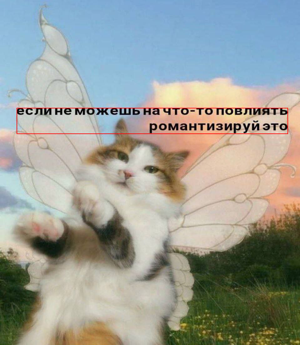

[53, 345, 920, 428]
если не можешь на что-то повлиять романтизируй это
---


In [8]:
test_blocks = get_coords_and_text(Image.open("memes/" + test + ".jpg"), get_boxes_tesseract, True)

In [9]:
test_blocks

[{'coords': [53, 345, 920, 428],
  'text': 'если не можешь на что-то повлиять романтизируй это'}]

Напишем функцию, рассчитывающую метрики качества:

In [7]:
def levenshtein(s1, s2):
    m, n = len(s1), len(s2)
    dp = [[0]*(n+1) for _ in range(m+1)]

    for i in range(m+1):
        dp[i][0] = i
    for j in range(n+1):
        dp[0][j] = j

    for i in range(1, m+1):
        for j in range(1, n+1):
            if s1[i-1] == s2[j-1]:
                cost = 0
            else:
                cost = 1
            dp[i][j] = min(dp[i-1][j] + 1,     
                           dp[i][j-1] + 1,    
                           dp[i-1][j-1] + cost) 
    return dp[m][n]

def levenshtein_words(s1, s2):
    s1_words = re.split(r'\s+', s1.strip())
    s2_words = re.split(r'\s+', s2.strip())

    m, n = len(s1_words), len(s2_words)
    dp = [[0]*(n+1) for _ in range(m+1)]
    
    for i in range(m+1):
        dp[i][0] = i
    for j in range(n+1):
        dp[0][j] = j
    
    for i in range(1, m+1):
        for j in range(1, n+1):
            if s1_words[i-1] == s2_words[j-1]:
                cost = 0
            else:
                cost = 1
            dp[i][j] = min(
                dp[i-1][j] + 1,   
                dp[i][j-1] + 1,      
                dp[i-1][j-1] + cost  
            )
    return dp[m][n]

def char_accuracy(right_text, recognized_text):
    dist = levenshtein(right_text, recognized_text)
    return max(0, 1 - dist / len(right_text))

def word_accuracy(right_text, recognized_text):
    word_dist = levenshtein_words(right_text, recognized_text)
    return max(0, 1 - word_dist / len(re.split(r'\s+', right_text.strip())))

def metrics_for_block(right_text, recognized_text):
    return char_accuracy(right_text, recognized_text), word_accuracy(right_text, recognized_text)


def align_blocks(right_blocks, recognized_blocks, max_merge=3):
    
    remaining_pred = list(range(len(recognized_blocks)))  
    result = []

    for i, right in enumerate(right_blocks):
        best_acc = -1
        best_text = ""
        best_indices = []

        for k in range(1, min(max_merge, len(remaining_pred)) + 1):
            for combo in itertools.permutations(remaining_pred, k):
                merged = '\n'.join([recognized_blocks[j] for j in combo])
                acc = char_accuracy(right, merged)
                if acc > best_acc:
                    best_acc = acc
                    best_text = merged
                    best_indices = combo

        result.append({
            'right_block': right_blocks[i],
            'recognized_block': best_text,
            'accuracy': best_acc,
            'pred_indices': best_indices
        })

        for j in best_indices:
            remaining_pred.remove(j)

    for j in remaining_pred:
        result.append({
            'right_block': None,
            'recognized_block': recognized_blocks[j],
            'accuracy': 0.0,
            'pred_indices': [j]
        })

    return result

def normalize_text(text):
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\w\sа-яА-Я]', '', text)

    return text.lower().strip()

def metrics_for_image(img_id, boxes_func, show, *args, **kwargs):
    img_path = "memes/" + img_id + ".jpg"
    img = Image.open(img_path)
    blocks_recognized = get_coords_and_text(img, boxes_func, show, *args, **kwargs)
    blocks_right = re.split(r'\n\s*\n', captions[img_id].strip())

    aligned_blocks = align_blocks(blocks_right, [x['text'] for x in blocks_recognized])

    right_string_normalized = normalize_text(captions[img_id])
    recognized_string_normalized = normalize_text('\n'.join([x['recognized_block'] for x in aligned_blocks]))

    normalized_string_char_acc, normalized_string_word_acc = metrics_for_block(right_string_normalized, recognized_string_normalized)

    return normalized_string_char_acc, normalized_string_word_acc


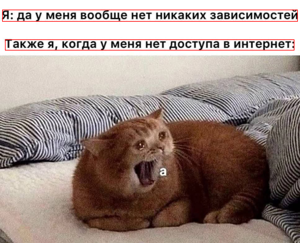

[7, 31, 959, 69]
Я: дау меня вообще нет никаких зависимостей
---
[16, 127, 948, 162]
Также я, когда у меня нет доступа в интернет:
---


(0.9662921348314607, 0.8333333333333334)

In [11]:
test = list(captions.keys())[30]
metrics_for_image(test, get_boxes_tesseract, True)

Теперь напишем функцию, прогоняющую весь датасет через определение качества и замеряющую среднюю метрику:

In [8]:
def avg_metrics(boxes_func, *args, **kwargs):
    chars = []
    words = []
    for id in captions.keys():
        char, word = metrics_for_image(id, boxes_func, False, *args, **kwargs)
        chars.append(char)
        words.append(word)
    
    return sum(chars) / len(chars), sum(words) / len(words)

In [13]:
avg_metrics(get_boxes_tesseract)

(0.4391940323814896, 0.368867298279063)

In [15]:
def tesseract_grid_search(boxes_func, param_grid):
    best_score = -1
    best_config = None

    keys, values = zip(*param_grid.items())
    all_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

    for combo in all_combinations:
        config_parts = [
            f"--oem {combo['oem']}",
            f"--psm {combo['psm']}",
        ]
        if combo['whitelist']:
            config_parts.append(f"-c tessedit_char_whitelist={combo['whitelist']}")
        config = " ".join(config_parts)

        char_acc, word_acc = avg_metrics(boxes_func, config=config)
        score = char_acc  + word_acc

        print(f"{config} "
              f"chars={char_acc:.3f} words={word_acc:.3f}")

        if score > best_score:
            best_score = score
            best_config = config

    print("\n=== Лучший конфиг ===")
    print(best_config)
    return best_config, best_score

In [16]:
param_grid = {
    "psm": [3, 4, 6, 7, 11],
    "oem": [1, 3],
    "whitelist": ["", "АБВГДЕЁЖЗИЙКЛМНОПРСТУФХЦЧЪЫЬЭЮЯабвгдеёжзийклмнопрстуфхцчъыьэюя0123456789 "]
}

tesseract_grid_search(get_boxes_tesseract, param_grid)

KeyboardInterrupt: 

Итак, сейчас лучший результат для tesseract при psm = 4 и отсутствии вайтлиста: accuracy по символам 44.7%, accuracy по словам 38.8%. Но при тестировании функций видели, что на многих фото вообще не распознается ничего: нужна предобработка.

In [9]:
def preprocess_image(img, grayscale=False, resize=None, blur=None, threshold=None, morph=None, clahe=False, edge_enhance=False, invert=False, sharpen=False, denoise=False):
    img_np = np.array(img)

    if grayscale and len(img_np.shape) == 3:
        img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

    if resize is not None:
        img_np = cv2.resize(
            img_np,
            None,
            fx=resize,
            fy=resize,
            interpolation=cv2.INTER_CUBIC
        )

    if clahe:
        img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        clahe_obj = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        img_np = clahe_obj.apply(img_np)

    if blur == "gaussian":
        img_np = cv2.GaussianBlur(img_np, (5,5), 0)

    elif blur == "median":
        img_np = cv2.medianBlur(img_np, 3)

    elif blur == "bilateral":
        img_np = cv2.bilateralFilter(img_np, 9, 75, 75)

    if threshold == "otsu":
        img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        _, img_np = cv2.threshold(
            img_np,
            0,
            255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )

    elif threshold == "binary":
        img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        _, img_np = cv2.threshold(
            img_np,
            127,
            255,
            cv2.THRESH_BINARY
        )

    elif threshold == "adaptive":
        img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        img_np = cv2.adaptiveThreshold(img_np, 255,
                                    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                    cv2.THRESH_BINARY, 11, 2)

    if morph:
        kernel = np.ones((3,3), np.uint8)

        if morph == "open":
            img_np = cv2.morphologyEx(img_np, cv2.MORPH_OPEN, kernel)

        elif morph == "close":
            img_np = cv2.morphologyEx(img_np, cv2.MORPH_CLOSE, kernel)

        elif morph == "dilate":
            img_np = cv2.dilate(img_np, kernel, iterations=1)

        elif morph == "erode":
            img_np = cv2.erode(img_np, kernel, iterations=1)

    if edge_enhance:
        img_np = cv2.Canny(img_np, 50, 150)

    if invert:
        img_np = cv2.bitwise_not(img_np)
    
    if sharpen:
        kernel = np.array([[0, -1, 0],
                        [-1, 5, -1],
                        [0, -1, 0]])
        img_np = cv2.filter2D(img_np, -1, kernel)

    if denoise:
        if len(img_np.shape) == 3:
            img_np = cv2.fastNlMeansDenoisingColored(img_np, h=10, hColor=10)
        else:
            img_np = cv2.fastNlMeansDenoising(img_np, h=10)

    return Image.fromarray(img_np)

def metrics_for_image_preprocessed(img_id, boxes_func, show=False, preprocess_params=None, *args, **kwargs):
    img_path = "memes/" + img_id + ".jpg"

    img = Image.open(img_path)
    if preprocess_params is not None:
        img = preprocess_image(img, **preprocess_params)

    blocks_recognized = get_coords_and_text(img, boxes_func, show, *args, **kwargs)
    blocks_right = re.split(r'\n\s*\n', captions[img_id].strip())

    aligned_blocks = align_blocks(blocks_right, [x['text'] for x in blocks_recognized])

    right_string_normalized = normalize_text(captions[img_id])
    recognized_string_normalized = normalize_text('\n'.join([x['recognized_block'] for x in aligned_blocks]))

    normalized_string_char_acc, normalized_string_word_acc = metrics_for_block(right_string_normalized, recognized_string_normalized)

    return normalized_string_char_acc, normalized_string_word_acc

def avg_metrics_preprocessed(boxes_func, preprocess_params=None, *args, **kwargs):
    chars = []
    words = []
    for id in captions.keys():
        char, word = metrics_for_image_preprocessed(id, boxes_func, False, preprocess_params, *args, **kwargs)
        chars.append(char)
        words.append(word)
    
    return sum(chars) / len(chars), sum(words) / len(words)

In [10]:
def preprocess_grid_search(boxes_func, param_grid, *args, **kwargs):
    best_score = -1
    best_params = None

    keys, values = zip(*param_grid.items())
    all_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

    for params in all_combinations:

        char_acc, word_acc = avg_metrics_preprocessed(
            boxes_func,
            preprocess_params=params,
            config="--oem 1 --psm 4"
        )

        score = char_acc + word_acc

        print(
            f"{params} "
            f"chars={char_acc:.3f} words={word_acc:.3f}"
        )

        if score > best_score:
            best_score = score
            best_params = params

    print("\n=== Лучший preprocessing ===")
    print(best_params)
    print("score =", best_score)

    return best_params, best_score

In [20]:
preprocess_grid = {
    "resize": [0.5, 1, 3, 5, 10],
}

preprocess_grid_search(get_boxes_tesseract, preprocess_grid)

{'resize': 0.5} chars=0.419 words=0.355
{'resize': 1} chars=0.463 words=0.400
{'resize': 3} chars=0.455 words=0.330
{'resize': 5} chars=0.476 words=0.358
{'resize': 10} chars=0.402 words=0.300

=== Лучший preprocessing ===
{'resize': 1}
score = 0.8629347154530995


({'resize': 1}, 0.8629347154530995)

In [21]:
preprocess_grid = {
    "blur": [None, "gaussian", "median", "bilateral"],
}

preprocess_grid_search(get_boxes_tesseract, preprocess_grid)

{'blur': None} chars=0.463 words=0.400
{'blur': 'gaussian'} chars=0.444 words=0.350
{'blur': 'median'} chars=0.453 words=0.356
{'blur': 'bilateral'} chars=0.449 words=0.338

=== Лучший preprocessing ===
{'blur': None}
score = 0.8629347154530995


({'blur': None}, 0.8629347154530995)

In [22]:
preprocess_grid = {
    "grayscale": [False, True],
}

preprocess_grid_search(get_boxes_tesseract, preprocess_grid)

{'grayscale': False} chars=0.463 words=0.400
{'grayscale': True} chars=0.452 words=0.357

=== Лучший preprocessing ===
{'grayscale': False}
score = 0.8629347154530995


({'grayscale': False}, 0.8629347154530995)

In [25]:
preprocess_grid = {
    "threshold": [None, "otsu", "binary"],
}

preprocess_grid_search(get_boxes_tesseract, preprocess_grid)

{'threshold': None} chars=0.463 words=0.400
{'threshold': 'otsu'} chars=0.468 words=0.370
{'threshold': 'binary'} chars=0.499 words=0.391

=== Лучший preprocessing ===
{'threshold': 'binary'}
score = 0.8894695297803803


({'threshold': 'binary'}, 0.8894695297803803)

In [26]:
preprocess_grid = {
    "morph": [None, "open", "close", "dilate", "erode"],
}

preprocess_grid_search(get_boxes_tesseract, preprocess_grid)

{'morph': None} chars=0.463 words=0.400
{'morph': 'open'} chars=0.488 words=0.393
{'morph': 'close'} chars=0.370 words=0.311
{'morph': 'dilate'} chars=0.368 words=0.278
{'morph': 'erode'} chars=0.510 words=0.374

=== Лучший preprocessing ===
{'morph': 'erode'}
score = 0.8839194210299794


({'morph': 'erode'}, 0.8839194210299794)

In [29]:
preprocess_grid = {
    "clahe": [False, True],
}

preprocess_grid_search(get_boxes_tesseract, preprocess_grid)

{'clahe': False} chars=0.463 words=0.400
{'clahe': True} chars=0.375 words=0.302

=== Лучший preprocessing ===
{'clahe': False}
score = 0.8629347154530995


({'clahe': False}, 0.8629347154530995)

In [30]:
preprocess_grid = {
    "edge_enhance": [False, True],
}

preprocess_grid_search(get_boxes_tesseract, preprocess_grid)

{'edge_enhance': False} chars=0.463 words=0.400
{'edge_enhance': True} chars=0.280 words=0.116

=== Лучший preprocessing ===
{'edge_enhance': False}
score = 0.8629347154530995


({'edge_enhance': False}, 0.8629347154530995)

In [31]:
preprocess_grid = {
    "resize": [1, 3, 5],
    "blur": [None, "gaussian", "median", "bilateral"],
    "grayscale": [False, True],
    "morph": [None, "open", "erode"],
}

preprocess_grid_search(get_boxes_tesseract, preprocess_grid)

{'resize': 1, 'blur': None, 'grayscale': False, 'morph': None} chars=0.463 words=0.400
{'resize': 1, 'blur': None, 'grayscale': False, 'morph': 'open'} chars=0.488 words=0.393
{'resize': 1, 'blur': None, 'grayscale': False, 'morph': 'erode'} chars=0.510 words=0.374
{'resize': 1, 'blur': None, 'grayscale': True, 'morph': None} chars=0.452 words=0.357
{'resize': 1, 'blur': None, 'grayscale': True, 'morph': 'open'} chars=0.496 words=0.386
{'resize': 1, 'blur': None, 'grayscale': True, 'morph': 'erode'} chars=0.489 words=0.368
{'resize': 1, 'blur': 'gaussian', 'grayscale': False, 'morph': None} chars=0.444 words=0.350
{'resize': 1, 'blur': 'gaussian', 'grayscale': False, 'morph': 'open'} chars=0.459 words=0.360
{'resize': 1, 'blur': 'gaussian', 'grayscale': False, 'morph': 'erode'} chars=0.428 words=0.297
{'resize': 1, 'blur': 'gaussian', 'grayscale': True, 'morph': None} chars=0.394 words=0.326
{'resize': 1, 'blur': 'gaussian', 'grayscale': True, 'morph': 'open'} chars=0.449 words=0.354
{

: 

## EasyOCR

In [16]:
import easyocr

Сделаем функцию грид серча по парметрам универсальной:

In [11]:
def ocr_grid_search(boxes_func, param_grid):
    best_score = -1
    best_params = None

    keys, values = zip(*param_grid.items())
    all_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

    for combo in all_combinations:
        char_acc, word_acc = avg_metrics(boxes_func, **combo)
        score = char_acc + word_acc

        print(f"{combo} chars={char_acc:.3f} words={word_acc:.3f}")

        if score > best_score:
            best_score = score
            best_params = combo

    print("\n=== Лучшие параметры ===")
    print(best_params)
    return best_params, best_score

In [23]:
def get_boxes_easyocr(img, reader, decoder="greedy", beamWidth=5):

    results = reader.readtext(img, decoder=decoder, beamWidth=beamWidth)

    boxes = []
    for (bbox, text, conf) in results:
        x_coords = [p[0] for p in bbox]
        y_coords = [p[1] for p in bbox]

        x0, y0 = int(min(x_coords)), int(min(y_coords))
        x1, y1 = int(max(x_coords)), int(max(y_coords))

        boxes.append({"coords": [x0, y0, x1, y1], "text": text})

    return boxes

In [24]:
reader_easy = easyocr.Reader(["ru"], gpu=False, verbose=False)

param_grid_easy = {
    "reader": [reader_easy],
    "decoder": ["greedy", "beamsearch"],
    "beamWidth": [3, 5, 10],
}

ocr_grid_search(get_boxes_easyocr, param_grid_easy)

c:\Users\dielo\MemeTranslator\ocr_research\venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'reader': <easyocr.easyocr.Reader object at 0x0000013D4361AC60>, 'decoder': 'greedy', 'beamWidth': 3} chars=0.695 words=0.460
{'reader': <easyocr.easyocr.Reader object at 0x0000013D4361AC60>, 'decoder': 'greedy', 'beamWidth': 5} chars=0.695 words=0.460
{'reader': <easyocr.easyocr.Reader object at 0x0000013D4361AC60>, 'decoder': 'greedy', 'beamWidth': 10} chars=0.695 words=0.460


c:\Users\dielo\MemeTranslator\ocr_research\venv\Lib\site-packages\easyocr\utils.py:221: RuntimeWarning: overflow encountered in scalar add
  curr.entries[labeling].prTotal += prBlank + prNonBlank
c:\Users\dielo\MemeTranslator\ocr_research\venv\Lib\site-packages\easyocr\utils.py:248: RuntimeWarning: overflow encountered in scalar add
  curr.entries[newLabeling].prNonBlank += prNonBlank
c:\Users\dielo\MemeTranslator\ocr_research\venv\Lib\site-packages\easyocr\utils.py:249: RuntimeWarning: overflow encountered in scalar add
  curr.entries[newLabeling].prTotal += prNonBlank
c:\Users\dielo\MemeTranslator\ocr_research\venv\Lib\site-packages\easyocr\utils.py:219: RuntimeWarning: overflow encountered in scalar add
  curr.entries[labeling].prNonBlank += prNonBlank


{'reader': <easyocr.easyocr.Reader object at 0x0000013D4361AC60>, 'decoder': 'beamsearch', 'beamWidth': 3} chars=0.649 words=0.422
{'reader': <easyocr.easyocr.Reader object at 0x0000013D4361AC60>, 'decoder': 'beamsearch', 'beamWidth': 5} chars=0.649 words=0.422
{'reader': <easyocr.easyocr.Reader object at 0x0000013D4361AC60>, 'decoder': 'beamsearch', 'beamWidth': 10} chars=0.649 words=0.422

=== Лучшие параметры ===
{'reader': <easyocr.easyocr.Reader object at 0x0000013D4361AC60>, 'decoder': 'greedy', 'beamWidth': 3}


({'reader': <easyocr.easyocr.Reader at 0x13d4361ac60>,
  'decoder': 'greedy',
  'beamWidth': 3},
 1.1548605571501196)

## PaddleOCR

In [42]:
os.environ["FLAGS_enable_mkldnn"] = "0"  
os.environ["PADDLE_DISABLE_MKLDNN"] = "1"

from paddleocr import PaddleOCR

In [51]:
_paddle_cache = {
    True:  PaddleOCR(lang="ru", use_textline_orientation=True,  enable_mkldnn=False),
    False: PaddleOCR(lang="ru", use_textline_orientation=False, enable_mkldnn=False),
}

def get_boxes_paddle(img, cls):

    img = np.array(img)

    ocr = _paddle_cache[cls]
    result = ocr.predict(img)

    boxes = []
    for page in result:                      
        rec_texts  = page["rec_texts"]          
        rec_scores = page["rec_scores"]    
        rec_polys  = page["rec_polys"]          

        for text, conf, poly in zip(rec_texts, rec_scores, rec_polys):
            x_coords = poly[:, 0]
            y_coords = poly[:, 1]
            x0, y0 = int(x_coords.min()), int(y_coords.min())
            x1, y1 = int(x_coords.max()), int(y_coords.max())
            boxes.append({"coords": [x0, y0, x1, y1], "text": text})

    return boxes

Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\dielo\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\dielo\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\dielo\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\dielo\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('eslav_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\dielo\.paddl

In [52]:
param_grid_paddle = {
    "cls": [True, False],
}

ocr_grid_search(get_boxes_paddle, param_grid_paddle)

{'cls': True} chars=0.652 words=0.466
{'cls': False} chars=0.660 words=0.488

=== Лучшие параметры ===
{'cls': False}


({'cls': False}, 1.1477998954080437)

## Surya OCR

In [12]:
from surya.recognition import RecognitionPredictor
from surya.detection import DetectionPredictor
from surya.foundation import FoundationPredictor

c:\Users\dielo\MemeTranslator\ocr_research\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [51]:
_det_predictor = None
_rec_predictor = None
_foundation = None

def _init_surya():
    global _det_predictor, _rec_predictor, _foundation
    if _foundation is None:
        _foundation = FoundationPredictor()  
    if _det_predictor is None:
        _det_predictor = DetectionPredictor()
    if _rec_predictor is None:
        _rec_predictor = RecognitionPredictor(_foundation)
    return _det_predictor, _rec_predictor

def get_boxes_surya(img, conf_threshold=0.5):
    det_pred, rec_pred = _init_surya()

    predictions = rec_pred([img], task_names=['ocr_with_boxes'], det_predictor=det_pred)

    boxes = []

    for pred in predictions:
        for line in pred.text_lines:
            if line.bbox is None:
                continue

            x0, y0, x1, y1 = map(int, line.bbox)
            score = getattr(line, "confidence", 1.0)
            if score < conf_threshold:
                continue

            boxes.append({
                "coords": [x0, y0, x1, y1],
                "text": line.text
            })

    return boxes

Recognizing Text: 100%|██████████| 4/4 [00:07<00:00,  1.87s/it]


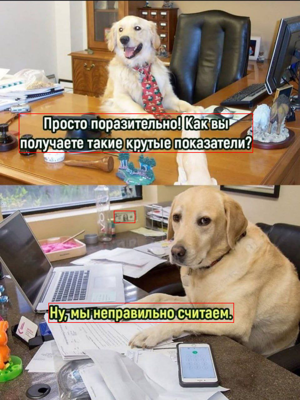

[60, 363, 809, 488]
Просто поразительно! Как вы получаете такие крутые показатели?
---
[364, 674, 432, 713]
CA.
---
[155, 969, 748, 1032]
Ну, мы неправильно считаемь
---


(0.9534883720930233, 0.8333333333333334)

In [55]:
test = list(captions.keys())[1]
metrics_for_image(test, get_boxes_surya, True)

In [54]:
param_grid_surya = {
    "conf_threshold": [0.3, 0.5, 0.7]
}

ocr_grid_search(get_boxes_surya, param_grid_surya)

Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.25s/it]


{'conf_threshold': 0.3} chars=0.782 words=0.670


Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.22s/it]


{'conf_threshold': 0.5} chars=0.788 words=0.674


Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.22s/it]

{'conf_threshold': 0.7} chars=0.807 words=0.700

=== Лучшие параметры ===
{'conf_threshold': 0.7}


({'conf_threshold': 0.7}, 1.5071843590760772)

In [57]:
param_grid_surya = {
    "conf_threshold": [0.6, 0.7, 0.8, 0.9]
}

ocr_grid_search(get_boxes_surya, param_grid_surya)

Recognizing Text: 100%|██████████| 2/2 [00:07<00:00,  3.52s/it]


{'conf_threshold': 0.6} chars=0.796 words=0.685


Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.27s/it]


{'conf_threshold': 0.7} chars=0.807 words=0.700


Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.26s/it]


{'conf_threshold': 0.8} chars=0.822 words=0.707


Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.29s/it]

{'conf_threshold': 0.9} chars=0.832 words=0.712

=== Лучшие параметры ===
{'conf_threshold': 0.9}


({'conf_threshold': 0.9}, 1.543918044271222)

In [59]:
param_grid_surya = {
    "conf_threshold": [0.9, 0.95, 0.99]
}

ocr_grid_search(get_boxes_surya, param_grid_surya)

Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.30s/it]


{'conf_threshold': 0.9} chars=0.832 words=0.712


Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.27s/it]


{'conf_threshold': 0.95} chars=0.789 words=0.694


Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.48s/it]

{'conf_threshold': 0.99} chars=0.562 words=0.509

=== Лучшие параметры ===
{'conf_threshold': 0.9}


({'conf_threshold': 0.9}, 1.543918044271222)

In [60]:
def preprocess_grid_search(boxes_func, param_grid, *args, **kwargs):
    best_score = -1
    best_params = None

    keys, values = zip(*param_grid.items())
    all_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

    for params in all_combinations:

        char_acc, word_acc = avg_metrics_preprocessed(
            boxes_func,
            preprocess_params=params,
            *args, **kwargs
        )

        score = char_acc + word_acc

        print(
            f"{params} "
            f"chars={char_acc:.3f} words={word_acc:.3f}"
        )

        if score > best_score:
            best_score = score
            best_params = params

    print("\n=== Лучший preprocessing ===")
    print(best_params)
    print("score =", best_score)

    return best_params, best_score

In [62]:
preprocess_grid = {
    "resize": [0.5, 1, 3, 5, 10],
}

preprocess_grid_search(get_boxes_surya, preprocess_grid, conf_threshold=0.9)

Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.28s/it]


{'resize': 0.5} chars=0.822 words=0.688


Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.31s/it]


{'resize': 1} chars=0.832 words=0.712


Recognizing Text: 100%|██████████| 2/2 [00:04<00:00,  2.46s/it]


...

Recognizing Text: 100%|██████████| 2/2 [00:10<00:00,  5.22s/it]


{'resize': 5} chars=0.601 words=0.543


Recognizing Text: 100%|██████████| 7/7 [00:54<00:00,  7.83s/it]

{'resize': 10} chars=0.586 words=0.513

=== Лучший preprocessing ===
{'resize': 1}
score = 1.543918044271222


({'resize': 1}, 1.543918044271222)

In [63]:
preprocess_grid = {
    "blur": [None, "gaussian", "median", "bilateral"],
}

preprocess_grid_search(get_boxes_surya, preprocess_grid, conf_threshold=0.9)

Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.30s/it]


{'blur': None} chars=0.832 words=0.712


Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.31s/it]


{'blur': 'gaussian'} chars=0.815 words=0.716


Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.28s/it]


{'blur': 'median'} chars=0.836 words=0.720


Recognizing Text: 100%|██████████| 3/3 [00:03<00:00,  1.10s/it]

{'blur': 'bilateral'} chars=0.811 words=0.718

=== Лучший preprocessing ===
{'blur': 'median'}
score = 1.5556219380652676


({'blur': 'median'}, 1.5556219380652676)

In [64]:
preprocess_grid = {
    "grayscale": [False, True],
}

preprocess_grid_search(get_boxes_surya, preprocess_grid, conf_threshold=0.9)

Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.30s/it]


{'grayscale': False} chars=0.832 words=0.712


Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.27s/it]

{'grayscale': True} chars=0.800 words=0.702

=== Лучший preprocessing ===
{'grayscale': False}
score = 1.543918044271222


({'grayscale': False}, 1.543918044271222)

In [65]:
preprocess_grid = {
    "threshold": [None, "adaptive", "otsu", "binary"],
}

preprocess_grid_search(get_boxes_surya, preprocess_grid, conf_threshold=0.9)

Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.27s/it]


{'threshold': None} chars=0.832 words=0.712


Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.23s/it]


{'threshold': 'adaptive'} chars=0.306 words=0.294


Recognizing Text: 100%|██████████| 4/4 [00:04<00:00,  1.00s/it]


{'threshold': 'otsu'} chars=0.529 words=0.462


Recognizing Text: 100%|██████████| 3/3 [00:03<00:00,  1.07s/it]

{'threshold': 'binary'} chars=0.592 words=0.514

=== Лучший preprocessing ===
{'threshold': None}
score = 1.543918044271222


({'threshold': None}, 1.543918044271222)

In [66]:
preprocess_grid = {
    "morph": [None, "open", "close", "dilate", "erode"],
}

preprocess_grid_search(get_boxes_surya, preprocess_grid, conf_threshold=0.9)

Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.32s/it]


{'morph': None} chars=0.832 words=0.712


Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.27s/it]


{'morph': 'open'} chars=0.835 words=0.722


Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.26s/it]


...

Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.27s/it]


{'morph': 'dilate'} chars=0.794 words=0.708


Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.30s/it]

{'morph': 'erode'} chars=0.868 words=0.759

=== Лучший preprocessing ===
{'morph': 'erode'}
score = 1.627288056962686


({'morph': 'erode'}, 1.627288056962686)

In [67]:
preprocess_grid = {
    "edge_enhance": [False, True],
}

preprocess_grid_search(get_boxes_surya, preprocess_grid, conf_threshold=0.9)

Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.27s/it]


{'edge_enhance': False} chars=0.832 words=0.712


Recognizing Text: 100%|██████████| 10/10 [00:08<00:00,  1.22it/s]

{'edge_enhance': True} chars=0.291 words=0.268

=== Лучший preprocessing ===
{'edge_enhance': False}
score = 1.543918044271222


({'edge_enhance': False}, 1.543918044271222)

In [68]:
preprocess_grid = {
    "clahe": [False, True],
}

preprocess_grid_search(get_boxes_surya, preprocess_grid, conf_threshold=0.9)

Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.27s/it]


{'clahe': False} chars=0.832 words=0.712


Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.26s/it]

{'clahe': True} chars=0.840 words=0.743

=== Лучший preprocessing ===
{'clahe': True}
score = 1.582721556839851


({'clahe': True}, 1.582721556839851)

In [70]:
preprocess_grid = {
    "invert": [False, True],
}

preprocess_grid_search(get_boxes_surya, preprocess_grid, conf_threshold=0.9)

Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.28s/it]


{'invert': False} chars=0.832 words=0.712


Recognizing Text: 100%|██████████| 3/3 [00:03<00:00,  1.12s/it]

{'invert': True} chars=0.828 words=0.725

=== Лучший preprocessing ===
{'invert': True}
score = 1.5535383585582148


({'invert': True}, 1.5535383585582148)

In [71]:
preprocess_grid = {
    "sharpen": [False, True],
}

preprocess_grid_search(get_boxes_surya, preprocess_grid, conf_threshold=0.9)

Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.27s/it]


{'sharpen': False} chars=0.832 words=0.712


Recognizing Text: 100%|██████████| 3/3 [00:03<00:00,  1.08s/it]

{'sharpen': True} chars=0.783 words=0.675

=== Лучший preprocessing ===
{'sharpen': False}
score = 1.543918044271222


({'sharpen': False}, 1.543918044271222)

In [69]:
preprocess_grid = {
    "denoise": [False, True],
}

preprocess_grid_search(get_boxes_surya, preprocess_grid, conf_threshold=0.9)

Recognizing Text: 100%|██████████| 2/2 [00:02<00:00,  1.30s/it]


{'denoise': False} chars=0.832 words=0.712


Recognizing Text: 100%|██████████| 4/4 [00:03<00:00,  1.00it/s]

{'denoise': True} chars=0.804 words=0.696

=== Лучший preprocessing ===
{'denoise': False}
score = 1.543918044271222


({'denoise': False}, 1.543918044271222)

In [74]:
preprocess_grid = {
    "invert": [False, True],
    "clahe": [True, False],
    "morph": [None, "open", "close",  "erode"],
    "blur": [None, "median"]
}

preprocess_grid_search(get_boxes_surya, preprocess_grid, conf_threshold=0.9)



Detecting bboxes: 100%|██████████| 1/1 [00:01<00:00,  1.73s/it]




Recognizing Text: 100%|██████████| 3/3 [00:06<00:00,  2.05s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:01<00:00,  1.88s/it]





Recognizing Text: 100%|██████████| 5/5 [00:09<00:00,  1.86s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:01<00:00,  1.95s/it]





Recognizing Text: 100%|██████████| 4/4 [00:08<00:00,  2.05s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:01<00:00,  2.00s/it]





Recognizing Text: 100%|██████████| 4/4 [00:05<00:00,  1.39s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:01<00:00,  1.99s/it]





Recognizing Text: 100%|██████████| 5/5 [00:05<00:00,  1.02s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.00s/it]



Recognizing Text: 100%|██████████| 3/3 [00:05<00:00,  1.98s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:01<00:00,  2.00s/it]






Recognizing Text: 100%|██████████| 9/9 [00:06<00:00,  1.44it/s]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2

{'invert': False, 'clahe': True, 'morph': None, 'blur': None} chars=0.840 words=0.743




Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.02s/it]




Recognizing Text: 100%|██████████| 3/3 [00:06<00:00,  2.25s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.05s/it]





Recognizing Text: 100%|██████████| 5/5 [00:10<00:00,  2.03s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.07s/it]





Recognizing Text: 100%|██████████| 4/4 [00:09<00:00,  2.31s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.04s/it]






Recognizing Text: 100%|██████████| 6/6 [00:08<00:00,  1.40s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.03s/it]





Recognizing Text: 100%|██████████| 5/5 [00:05<00:00,  1.11s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.07s/it]



Recognizing Text: 100%|██████████| 3/3 [00:06<00:00,  2.17s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:01<00:00,  1.99s/it]





Recognizing Text: 100%|██████████| 8/8 [00:06<00:00,  1.29it/s]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2

{'invert': False, 'clahe': True, 'morph': None, 'blur': 'median'} chars=0.839 words=0.721




Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.02s/it]



Recognizing Text: 100%|██████████| 2/2 [00:05<00:00,  2.76s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.03s/it]





Recognizing Text: 100%|██████████| 5/5 [00:10<00:00,  2.09s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.09s/it]




Recognizing Text: 100%|██████████| 3/3 [00:10<00:00,  3.46s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.05s/it]





Recognizing Text: 100%|██████████| 4/4 [00:06<00:00,  1.52s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.02s/it]





Recognizing Text: 100%|██████████| 5/5 [00:05<00:00,  1.14s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.10s/it]



Recognizing Text: 100%|██████████| 3/3 [00:06<00:00,  2.09s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.02s/it]







Recognizing Text: 100%|██████████| 9/9 [00:10<00:00,  1.20s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.

...



Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.02s/it]



Recognizing Text: 100%|██████████| 2/2 [00:05<00:00,  2.74s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.04s/it]





Recognizing Text: 100%|██████████| 4/4 [00:08<00:00,  2.24s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.07s/it]






Recognizing Text: 100%|██████████| 5/5 [00:16<00:00,  3.36s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.06s/it]




Recognizing Text: 100%|██████████| 3/3 [00:05<00:00,  1.73s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.03s/it]





Recognizing Text: 100%|██████████| 5/5 [00:05<00:00,  1.14s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.06s/it]



Recognizing Text: 100%|██████████| 3/3 [00:06<00:00,  2.03s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.03s/it]







Recognizing Text: 100%|██████████| 10/10 [00:07<00:00,  1.27it/s]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00, 

{'invert': True, 'clahe': False, 'morph': 'erode', 'blur': None} chars=0.896 words=0.792




Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.05s/it]



Recognizing Text: 100%|██████████| 2/2 [00:05<00:00,  2.81s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.05s/it]





Recognizing Text: 100%|██████████| 4/4 [00:08<00:00,  2.23s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.09s/it]






Recognizing Text: 100%|██████████| 5/5 [00:16<00:00,  3.33s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.08s/it]




Recognizing Text: 100%|██████████| 3/3 [00:05<00:00,  1.72s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.04s/it]





Recognizing Text: 100%|██████████| 5/5 [00:05<00:00,  1.13s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.09s/it]



Recognizing Text: 100%|██████████| 3/3 [00:06<00:00,  2.04s/it]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.18s/it]






Recognizing Text: 100%|██████████| 9/9 [00:07<00:00,  1.14it/s]


Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.

{'invert': True, 'clahe': False, 'morph': 'erode', 'blur': 'median'} chars=0.902 words=0.791

=== Лучший preprocessing ===
{'invert': True, 'clahe': False, 'morph': 'erode', 'blur': 'median'}
score = 1.693203709819481


({'invert': True, 'clahe': False, 'morph': 'erode', 'blur': 'median'},
 1.693203709819481)



Detecting bboxes: 100%|██████████| 1/1 [00:01<00:00,  1.75s/it]




Recognizing Text: 100%|██████████| 4/4 [00:13<00:00,  3.41s/it]


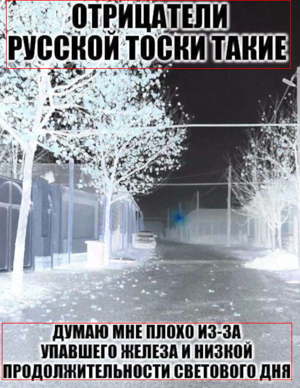

[20, 0, 957, 226]
ОТРИЦАТЕЛИ<br>Русской тоски такие
---
[6, 1065, 961, 1253]
ДУМАЮ МНЕ ПЛОХО ИЗ-ЗА УПАВШЕГО ЖЕЛЕЗА И НИЗКОЙ ПРОДОЛЖИТЕЛЬНОСТИ СВЕТОВОГО ДНЯ
---


(0.9814814814814815, 0.8666666666666667)

In [102]:
test = list(captions.keys())[34]

metrics_for_image_preprocessed(test, get_boxes_surya, True, preprocess_params={'invert': True, 'clahe': False, 'morph': 'erode', 'blur': 'median'}, conf_threshold=0.9)


| Библиотека | accuracy в символах, без предобработки | accuracy в словах, без предобработки | accuracy в символах, с предобработкой | accuracy в словах, с предобработкой |
| :--- | :---- | :---- | :---- | :--- |
| Tesseract | 44.7% | 38.8% | 49.9% | 37.1% |
| Easy | 69.5% | 46.0% | tbd но точно не побъет surya | tbd но точно не побъет surya |
| Paddle | 66.0% | 48.8% | tbd но точно не побъет surya | tbd но точно не побъет surya |
| Surya | 83.2% | 71.2% | 90.2% | 79.1% |
